In [2]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
from scipy import stats
import emcee
import time
import math
import corner
import dynesty
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
import warnings

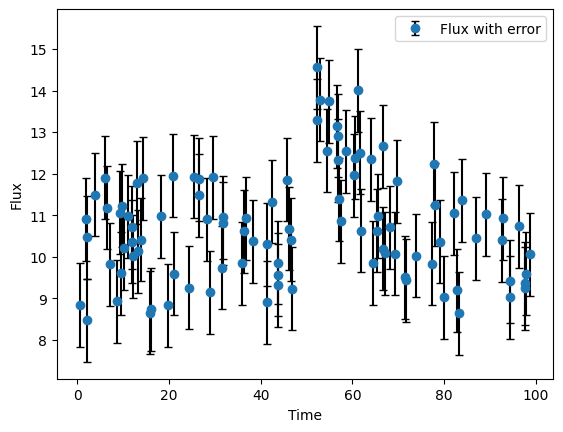

In [3]:
data=np.load("Transient.npy")
times=data[:,0]
flux=data[:,1]
err=data[:,2]
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.legend()
plt.show()

Model definition 

In [4]:
def burst(params):
    A,b,t0,alpha=params
    array=np.full_like(times,1)
    array[times<=t0]=b
    array[times>t0]=b+A*np.exp(-alpha*(times[times>t0]-t0))
    return array

def gaussian(params):
    A,b,t0,sigmaW=params
    return b+A*np.exp(-(((times-t0)/sigmaW)**2 ) / 2)

def LogLikelihood(params, model):
    if model =='burst':
        y= burst(params)
    elif model == 'gaussian':
        y = gaussian(params)


    # I don't consider the normalization here because I'm interested in the ratio of the evidences
    # (In general for model selection is important!) 
    return  -0.5 * np.sum(((flux - y) / err) ** 2)


prior definition 

In [5]:
#Prior definition 
#Nasted sampling works in a uniform prior space [0,1]

t0min,t0max = 0,100
Amin,Amax=0,50
bmin,bmax=0,50
alphamin,alphamax=np.exp(-5),np.exp(5)
sigmaWmin,sigmaWmax=np.exp(-2),np.exp(2)

def prior_transform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u) 
    """"we want to trasform a value uniformly distributed in the interval [0,1] in a uniform inteval [min,max]"""

    #loc = minimum value, scale= length of the interval
    #uniform prior for A, between Amin and Amax, value on x corresponding to the u percentile 
    # ppf= inverse of cdf 
    x[0] = stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0]) 
    x[1] = stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='burst':
        x[3] = stats.loguniform.ppf(u[3],alphamin,alphamax)
    elif model =='gaussian':
        x[3] = stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)

    return x

Let's try the burst model with nasted sampling

In [ ]:
""" Nlive=number of live points. Larger numbers result in a more finely sampled posterior (more accurate evidence), 
but also a larger number of iterations required to converge.  """

ndim=4 
with warnings.catch_warnings():
    # Potentially dangerous, but hey I know what I'm doing. 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    sampler = dynesty.NestedSampler(LogLikelihood, prior_transform, ndim,logl_args=['burst'],ptform_args=['burst'],nlive=300, sample='rwalk')
    sampler.run_nested()    #actual nested sampling run
    sresults = sampler.results

iter: 7528 | +500 | bound: 78 | nc: 1 | ncall: 155927 | eff(%):  5.165 | loglstar:   -inf < -48.761 <    inf | logz: -63.034 +/-  0.166 | dlogz:  0.001 >  0.509                                      

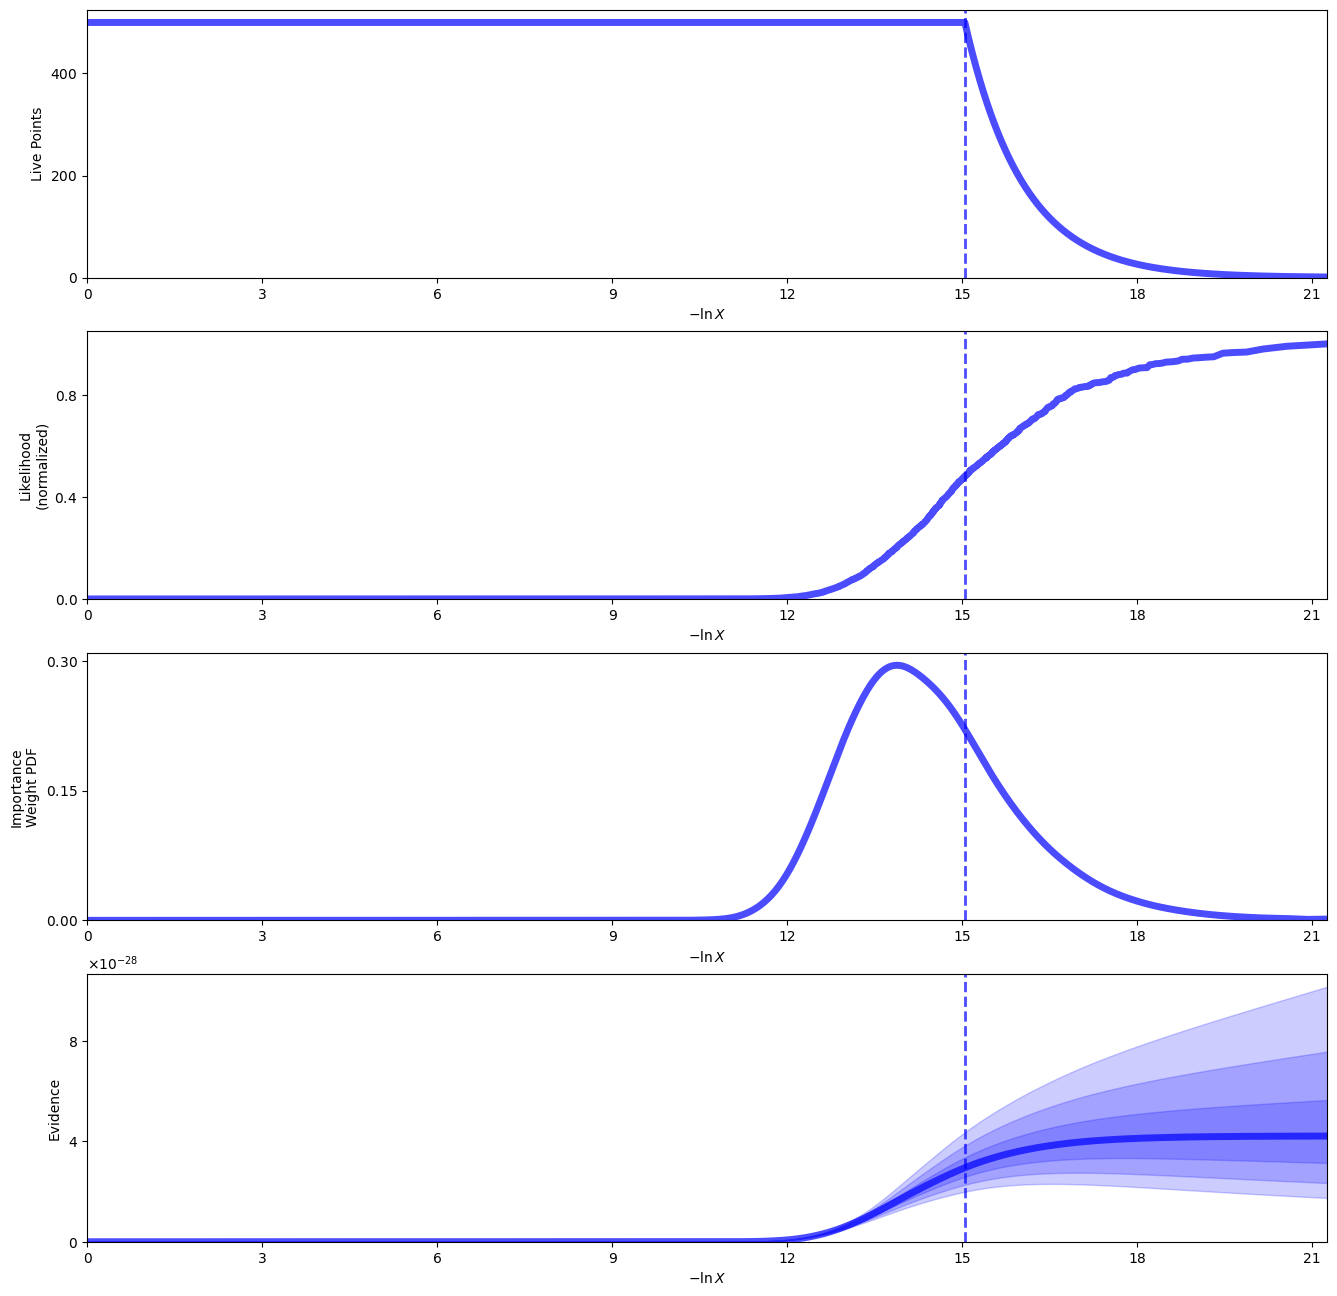

In [7]:
rfig, raxes = dyplot.runplot(sresults)

Parameter space in 1D. 
The live points started out scattereed across the prior volume, then move inwards as the sampler climbs the likelihood.

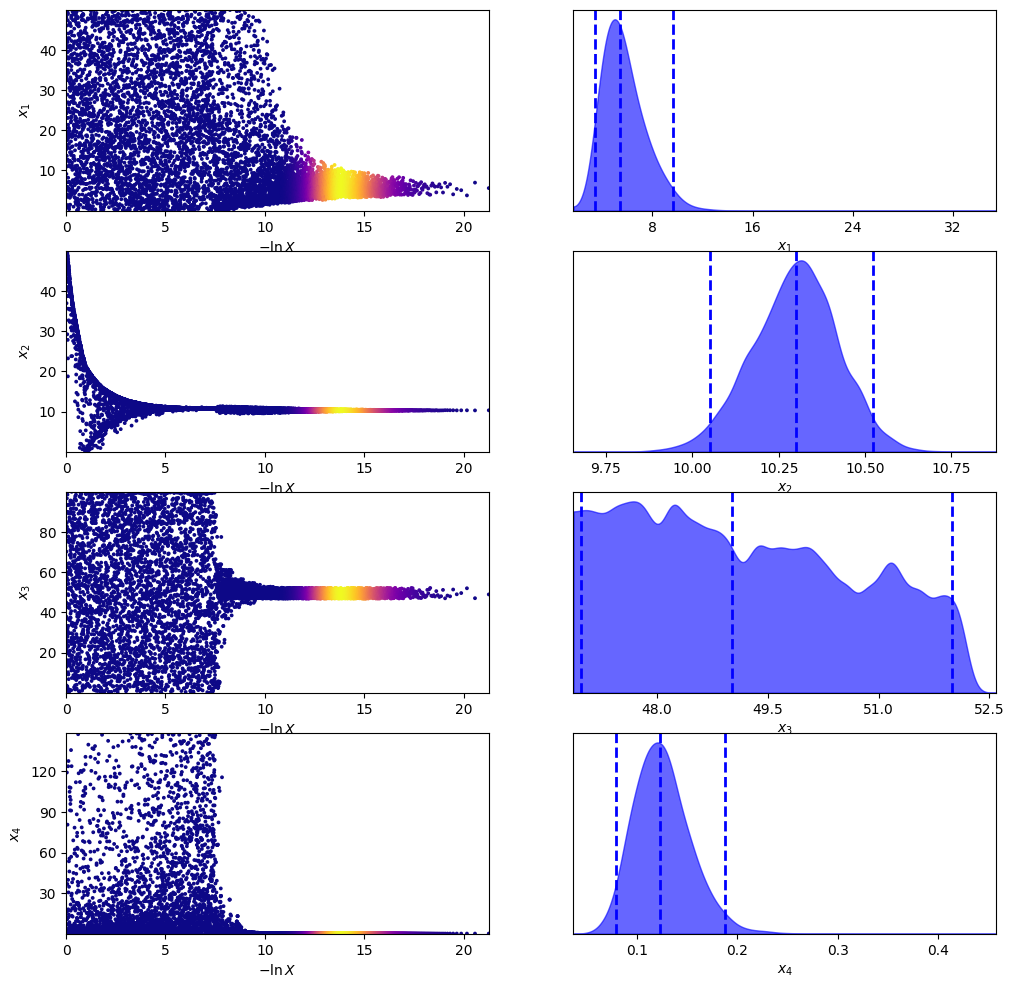

In [8]:
tfig, taxes = dyplot.traceplot(sresults)

In [9]:
#samples without weights are meaningless
samples = sresults.samples                  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

print(samples.shape) #samples for the 4 parameters


(8028, 4)


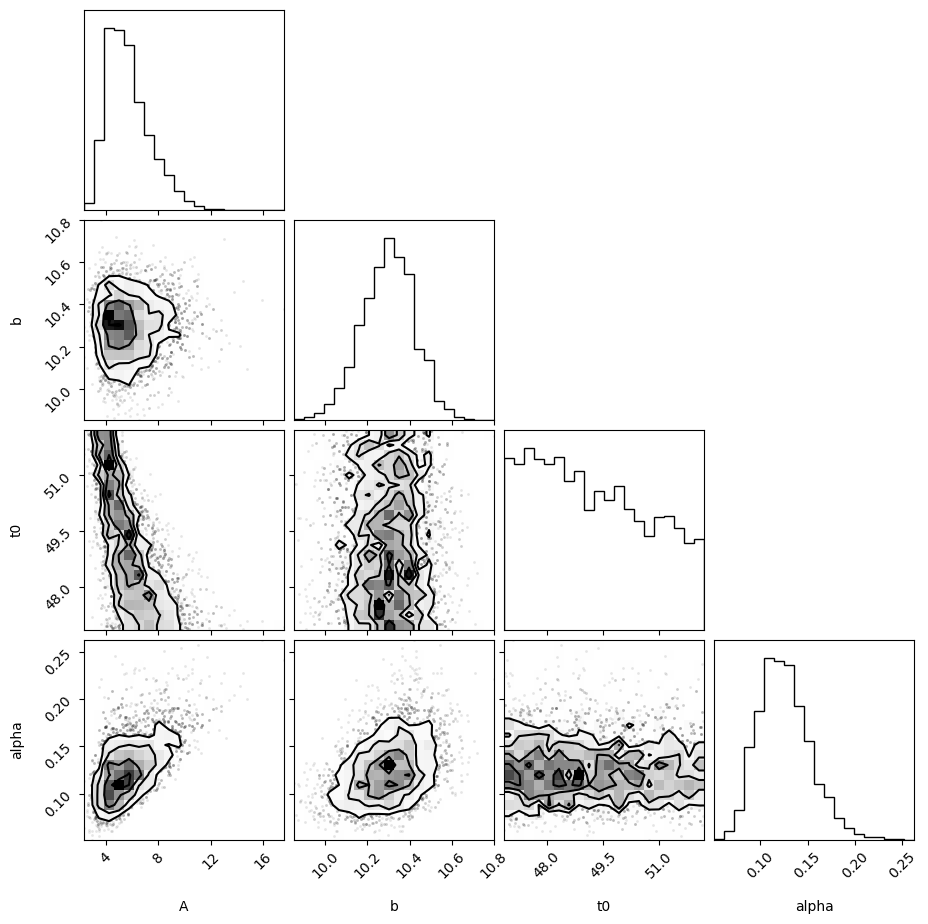

In [10]:
labels = ["A","b","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [11]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights) for samps in samples.T]    #trasposing samples for quantiles calculation for each parameter      
# 5% quantiles, median, 95% quantiles for each parameter

for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

A   5.442367414834671 +3.497171882094948 -1.8170712150041455
b   10.301492394797778 +0.18962746397773955 -0.21493620803955515
t0   49.020918748367095 +2.783030886722699 -1.9477556790036985
alpha   0.12339365437897717 +0.051259892949601704 -0.03776205081213152


In [12]:
sresults.summary()

Summary
nlive: 500
niter: 7528
ncall: 155427
eff(%):  5.165
logz: -63.034 +/-  0.294


In [13]:
# Compute weighted mean and covariance.
mean, cov = dyfunc.mean_and_cov(samples, weights)
print('Mean and covariance of parameters are: ' + str(mean) + '\n' + str(cov))

Mean and covariance of parameters are: [ 5.74953031 10.29671861 49.20289072  0.12560968]
[[ 2.81402310e+00  9.55857950e-03 -1.69719512e+00  2.75393239e-02]
 [ 9.55857950e-03  1.50590528e-02 -1.84330381e-03  1.25794375e-03]
 [-1.69719512e+00 -1.84330381e-03  2.24072682e+00 -2.00801418e-03]
 [ 2.75393239e-02  1.25794375e-03 -2.00801418e-03  7.78351013e-04]]


## Gaussian profile



In [14]:
ndim =4 
with warnings.catch_warnings():
    # Potentially dangerous, but hey I know what I'm doing. 
    # Those warnings come from regions where the likelihood is ~zero
    warnings.simplefilter("ignore", category=RuntimeWarning)
    
    samplerG = dynesty.NestedSampler(LogLikelihood, prior_transform, ndim,logl_args=['gaussian'],ptform_args=['gaussian'],nlive=300, sample='rwalk')
    samplerG.run_nested()          #actual nested sampling run
    sresults2 = samplerG.results


iter: 4836 | +300 | bound: 85 | nc: 1 | ncall: 101693 | eff(%):  5.065 | loglstar:   -inf < -52.423 <    inf | logz: -67.297 +/-  0.215 | dlogz:  0.001 >  0.309                                      

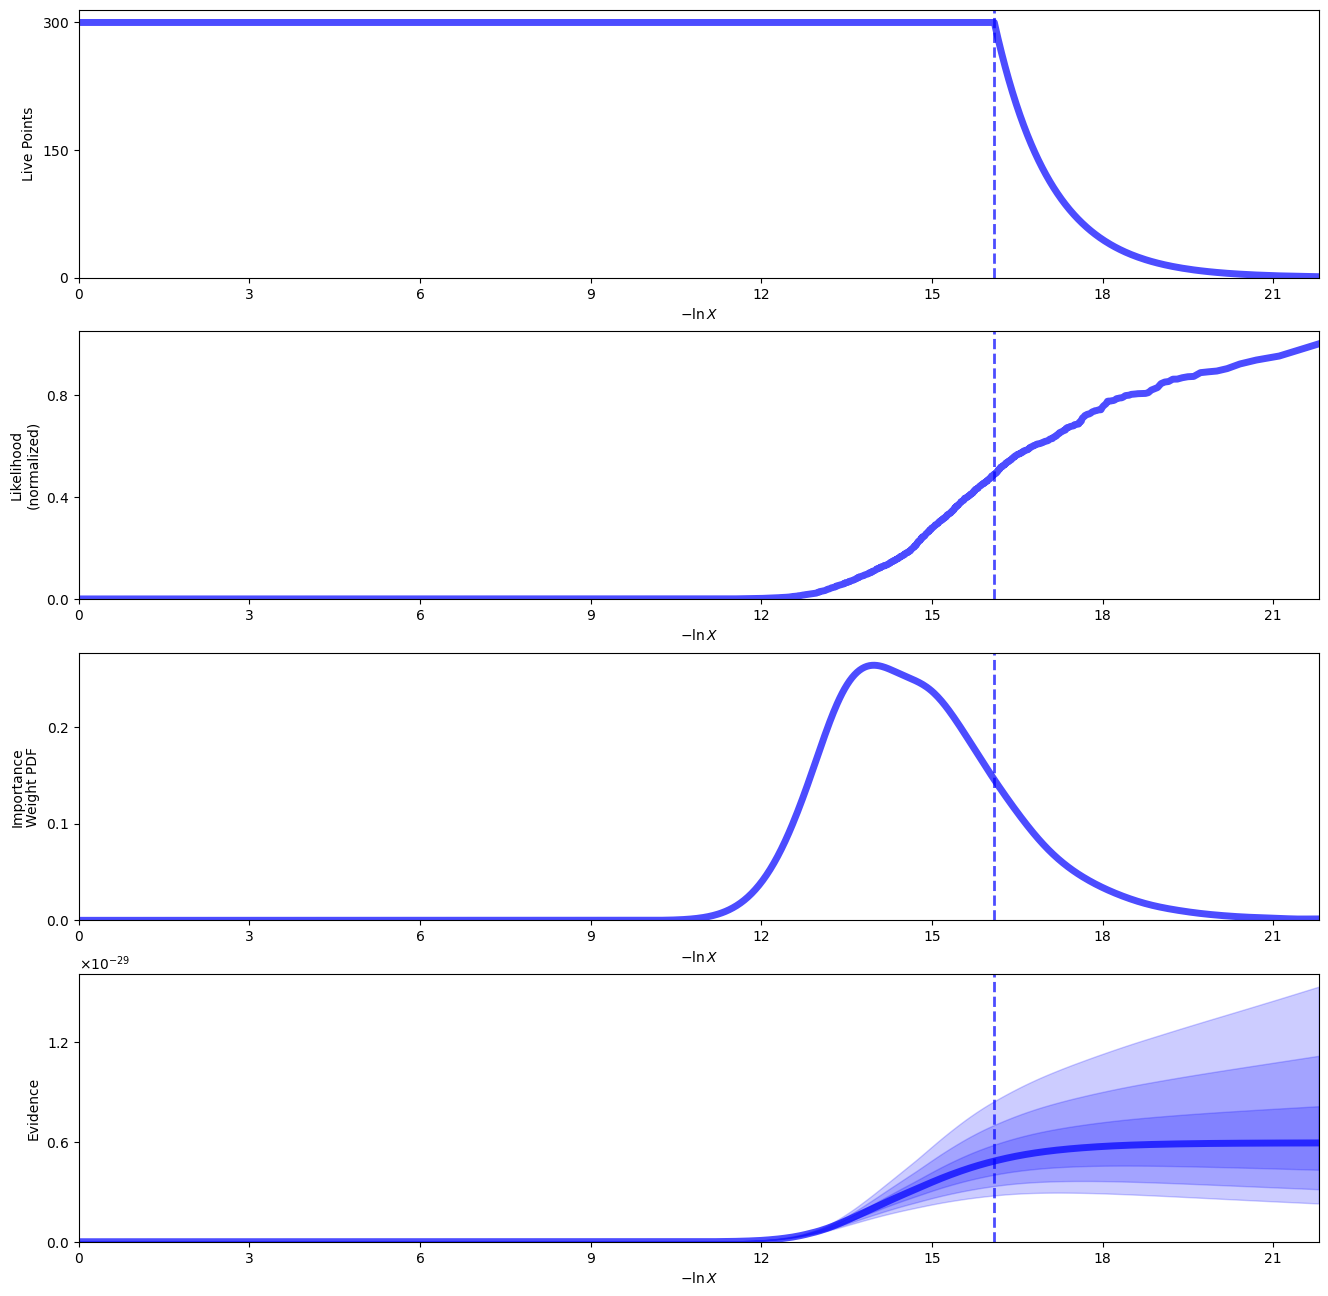

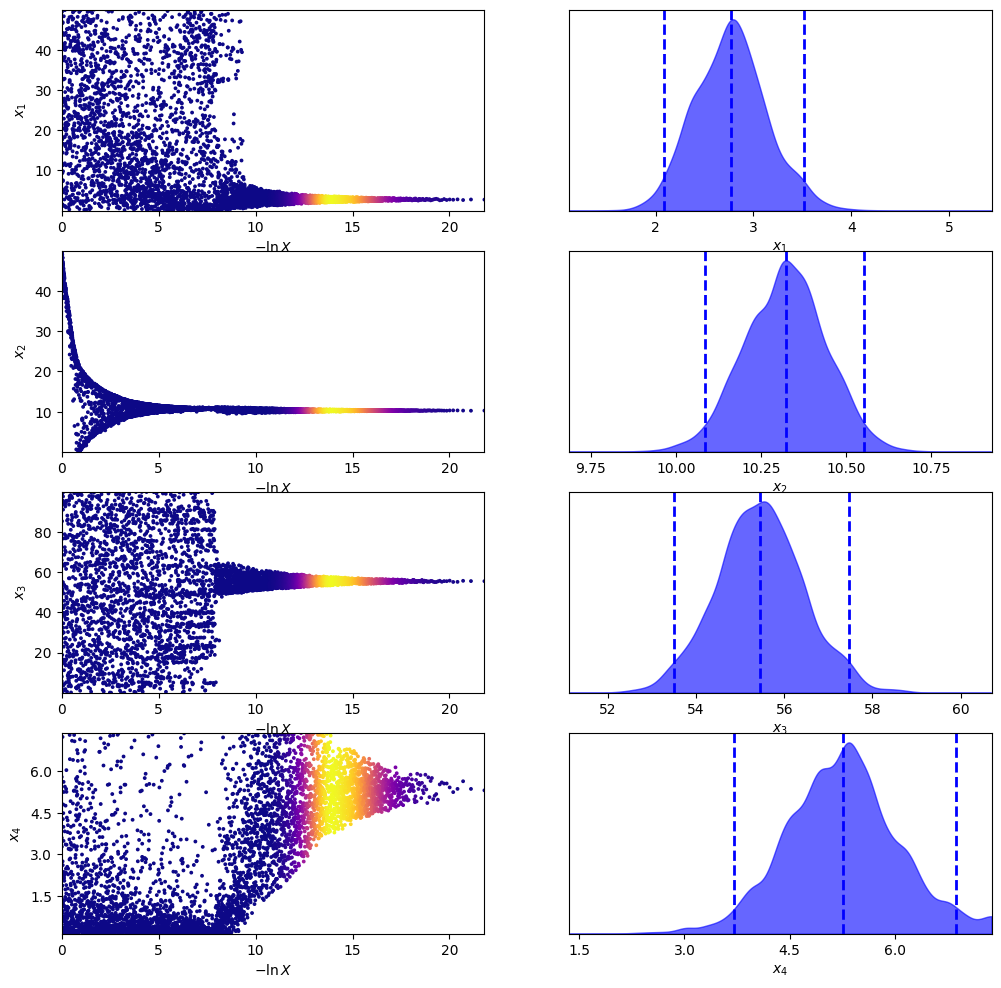

In [15]:
rfig, raxes = dyplot.runplot(sresults2)
tfig, taxes = dyplot.traceplot(sresults2)

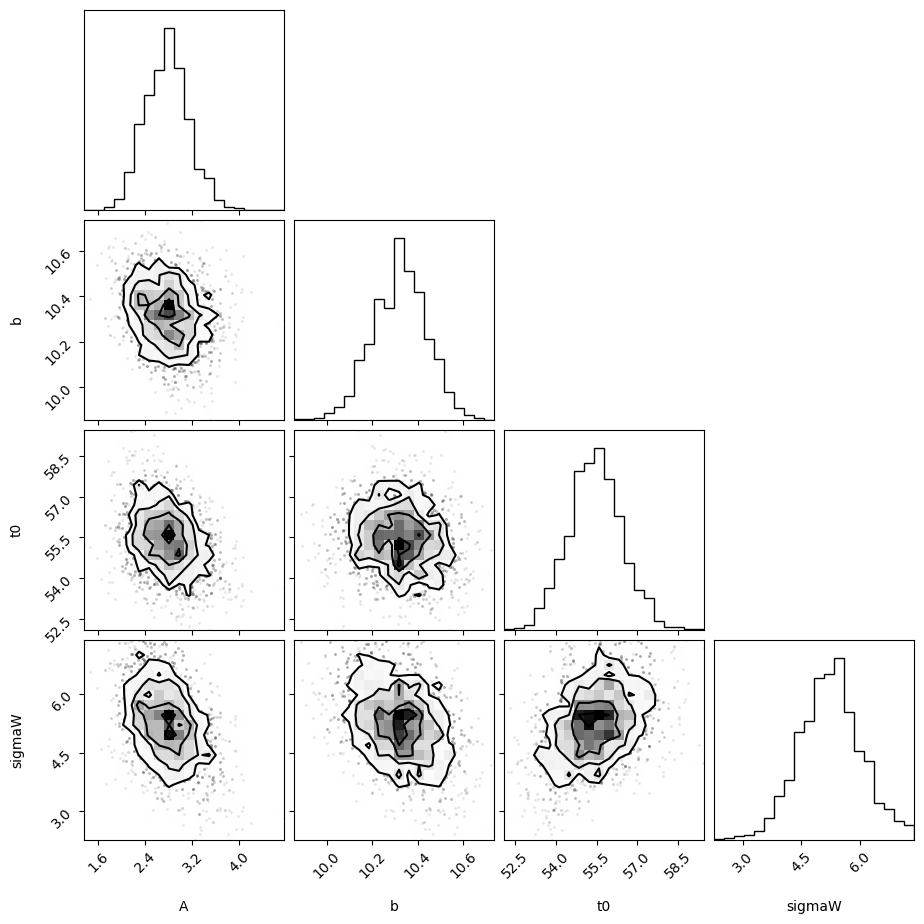

In [16]:
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["A","b","t0","sigmaW"]

samples_equal2 = dyfunc.resample_equal(samples2, weights2)
corner.corner(samples_equal2,labels=labels);

In [17]:
sresults2.summary()

Summary
nlive: 300
niter: 4836
ncall: 101393
eff(%):  5.065
logz: -67.297 +/-  0.316


### Z is often the symbol for bayesian evidence 

We are using the Bayes factor, which is numerically equivalent to ODDs ratios when we consider equal hyperpriors (which are the prior of our model themselves)

$$O_{21} = B_{21} \, \frac{p(M_2\,|\,I)}{p(M_1\,|\,I)},$$

The evidence is 


$$ E(M) \equiv p(D\,|\,M, I) = \int p(D\,|\,M, \theta, I) \, p(\theta\,|\,M, I) \, d\theta, $$

that is a ratio of data likelihoods averaged over all allowed values of the model parameters. 

In [18]:
evidence_burst = sresults.logz[-1]  #it is given in log 
print("Bayesian evidence BURST", np.exp(evidence_burst))

evidence_gauss = sresults2.logz[-1] 
print("Bayesian evidence GAUSS", np.exp(evidence_gauss))

Bayesian evidence BURST 4.214486769699595e-28
Bayesian evidence GAUSS 5.930714228568425e-30


In [19]:
ODDS_ratio=np.exp(sresults.logz[-1])/np.exp(sresults2.logz[-1])
print("ODDS ratio BURST/GAUSS", ODDS_ratio)

ODDS ratio BURST/GAUSS 71.06204425427022


Which is very strong in favour of the BURST MODEL

Let's plot some model

In [20]:
random.seed(42) 

sampB = samples_equal[np.random.choice(len(samples_equal),size=100)]   #let's choose 100 samples from samples_equal
i_mapB = np.argmax(weights)      
map_pointB = samples[i_mapB]


sampG = samples_equal2[np.random.choice(len(samples_equal2),size=100)]
i_mapG = np.argmax(weights2) 
map_pointG = samples2[i_mapG]



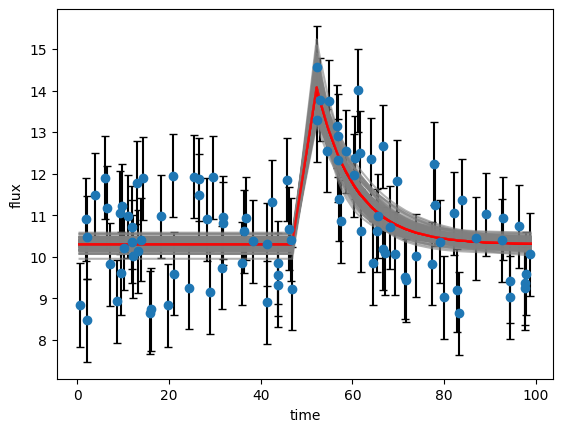

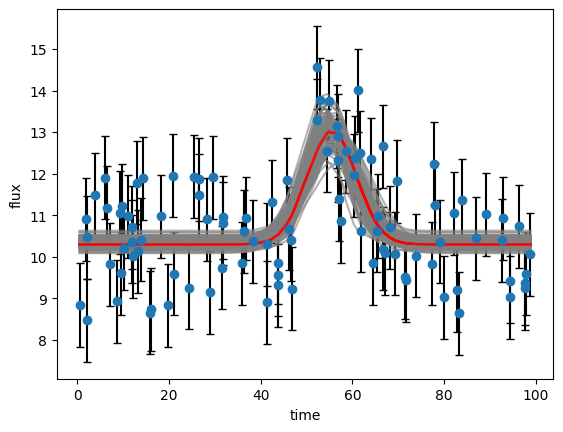

In [21]:
plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
for i in range(len(sampB)):
    y = burst(sampB[i])
    z= burst(map_pointB)
    plt.plot(times,y,alpha=0.6, c='gray')
    plt.plot(times,z,alpha=0.6, c='red')
plt.xlabel("time")
plt.ylabel("flux")
plt.show()

plt.errorbar(times, flux, yerr=err, fmt='o', ecolor='black', capsize=3, label='Flux with error')
for i in range(len(sampG)):
    y = gaussian(sampG[i])
    z= gaussian(map_pointG)
    plt.plot(times,y,alpha=0.6, c='gray')
    plt.plot(times,z,alpha=0.6, c='red')
plt.xlabel("time")
plt.ylabel("flux");